### Prework & Feature engineering

In [55]:
import pandas as pd

train_df = pd.read_csv("Parte 2/entrenamiento.csv")

In [56]:
## Relación superficie cubierta / total

train_df["covered_ratio"] = train_df["surface_covered"] / train_df["surface_total"]

## Generamos variable de año de creación del aviso de venta

train_df["created_on"] = pd.to_datetime(train_df["created_on"], errors="coerce")
train_df["year_created"] = train_df["created_on"].dt.year
train_df["month_created"] = train_df["created_on"].dt.month
train_df["age_of_ad"] = (pd.to_datetime("today") - train_df["created_on"]).dt.days

## Filtro los datos de precios vacíos

print(len(train_df))

train_df = train_df[train_df["price"].notna()] 

print(len(train_df))

992192
947811


In [57]:
import pandas as pd

# detectar 9999 y reemplazar por 2025-09-28
mask_9999 = train_df["end_date"].astype("string").str.strip().str.startswith("9999", na=False)
n = int(mask_9999.sum())
train_df.loc[mask_9999, "end_date"] = "2025-09-28"

# convertir a datetime (ya sin 9999)
train_df["end_date"] = pd.to_datetime(train_df["end_date"], errors="coerce")

print(f"Reemplazados {n} registros con año 9999.")

Reemplazados 178223 registros con año 9999.


In [58]:
# Filtrar por moneda USD y tipo de operación Venta
# Usar .copy() para crear un nuevo DataFrame
df_conv = train_df[
    (train_df["currency"] == "USD") & 
    (train_df["operation_type"] == 'Venta')
].copy()  # Cambiar por: "Alquiler" / "Alquiler temporal"

# Calcular precio por metro cuadrado, reemplazando valores 0 por NA
df_conv.loc[:, "price_m2"] = df_conv["price"] / df_conv["surface_total"].replace(0, pd.NA)

# Filtrar para mantener solo price_m2 positivos
df_conv = df_conv[df_conv["price_m2"] > 0]

print(f"Registros finales: {len(df_conv)}")

Registros finales: 280121


C:\Users\60083400\AppData\Local\Temp\ipykernel_10220\4048331409.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace([np.inf, -np.inf], np.nan)


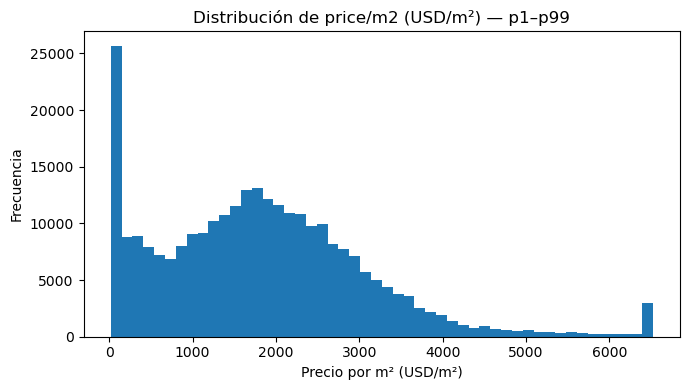

Filas totales en df_conv: 280121
Con price_m2 válido: 280121 | Tras p1–p99: 280121
count    2.801210e+05
mean     1.907241e+03
std      4.851061e+03
min      1.000000e-01
1%       1.750000e+01
10%      1.800000e+02
25%      8.750000e+02
50%      1.739726e+03
75%      2.549020e+03
90%      3.359375e+03
99%      6.521739e+03
max      1.817667e+06
Name: price_m2, dtype: float64


In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Serie limpia para graficar
s = (df_conv["price_m2"]
     .replace([np.inf, -np.inf], np.nan)
     .dropna())

# (Opcional) Recorte p1–p99 para que la cola no distorsione la figura
p1, p99 = s.quantile([0.01, 0.99])
s_clip = s.clip(lower=p1, upper=p99)

plt.figure(figsize=(7,4))
plt.hist(s_clip, bins=50)
plt.xlabel("Precio por m² (USD/m²)")
plt.ylabel("Frecuencia")
plt.title("Distribución de price/m2 (USD/m²) — p1–p99")
plt.tight_layout()
plt.show()

print(f"Filas totales en df_conv: {len(df_conv)}")
print(f"Con price_m2 válido: {s.size} | Tras p1–p99: {s_clip.size}")
print(s.describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))

In [60]:
# calculo la media de price_m2

mean_price_m2 = df_conv["price_m2"].mean()

print(f"Media de price_m2: {mean_price_m2:.2f} USD/m²")

Media de price_m2: 1907.24 USD/m²


In [61]:
# Guardar el DataFrame convertido antes del procesamiento FastAI
df_conv.to_parquet("./train_2_Prework.parquet")

## Quick prework with fastai

In [62]:
# Importar las librerías necesarias
from fastai.tabular.all import *
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia en kilómetros entre dos puntos usando la fórmula de Haversine
    """
    try:
        # Convertir a float para asegurar que los valores son numéricos
        lat1, lon1, lat2, lon2 = float(lat1), float(lon1), float(lat2), float(lon2)
        
        # Validar que las coordenadas están en rangos válidos
        if not (-90 <= lat1 <= 90) or not (-90 <= lat2 <= 90):
            print(f"Error: Latitud fuera de rango: lat1={lat1}, lat2={lat2}")
            return None
        if not (-180 <= lon1 <= 180) or not (-180 <= lon2 <= 180):
            print(f"Error: Longitud fuera de rango: lon1={lon1}, lon2={lon2}")
            return None

        R = 6371  # Radio de la Tierra en kilómetros

        # Convertir a radianes
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        
        # Calcular diferencias
        dlat = lat2 - lat1
        dlon = lon2 - lon1

        # Fórmula de Haversine
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = R * c

        return distance
    except Exception as e:
        print(f"Error en el cálculo de distancia: {e}")
        print(f"Valores recibidos: lat1={lat1}, lon1={lon1}, lat2={lat2}, lon2={lon2}")
        return None

def calcular_indice_urbanidad(lat, lon):
    """
    Calcula un índice de urbanidad basado en la distancia a centros urbanos
    ponderada por su población.
    """
    try:
        lat, lon = float(lat), float(lon)
        if not (-90 <= lat <= 90) or not (-180 <= lon <= 180):
            print(f"Error: Coordenadas fuera de rango: lat={lat}, lon={lon}")
            return None
            
        total_ponderacion = 0
        poblacion_total = sum(ciudad['poblacion'] for ciudad in CENTROS_URBANOS.values())
        
        for ciudad, data in CENTROS_URBANOS.items():
            distancia = haversine_distance(lat, lon, data['lat'], data['lon'])
            if distancia is not None:
                ponderacion = (data['poblacion'] / poblacion_total) * (1 / (distancia + 1))
                total_ponderacion += ponderacion
            else:
                print(f"Error en el cálculo de distancia para {ciudad}")
                return None
        
        return total_ponderacion
    except Exception as e:
        print(f"Error en el cálculo del índice de urbanidad: {e}")
        return None

# Definir principales centros urbanos con sus coordenadas y población
CENTROS_URBANOS = {
    'CABA': {'lat': -34.6037, 'lon': -58.3816, 'poblacion': 3075646},
    'Córdoba': {'lat': -31.4201, 'lon': -64.1888, 'poblacion': 1453600},
    'Rosario': {'lat': -32.9468, 'lon': -60.6393, 'poblacion': 1193605},
    'La Plata': {'lat': -34.9215, 'lon': -57.9545, 'poblacion': 753378},
    'Mar del Plata': {'lat': -38.0023, 'lon': -57.5575, 'poblacion': 614350},
    'San Miguel de Tucumán': {'lat': -26.8083, 'lon': -65.2176, 'poblacion': 592461},
    'Salta': {'lat': -24.7829, 'lon': -65.4232, 'poblacion': 554125},
    'Santa Fe': {'lat': -31.6187, 'lon': -60.7012, 'poblacion': 391231},
    'Resistencia': {'lat': -27.4513, 'lon': -58.9866, 'poblacion': 385726},
    'Mendoza': {'lat': -32.8908, 'lon': -68.8272, 'poblacion': 375685}
}

# Verificar coordenadas del Obelisco
OBELISCO_LAT = -34.6037
OBELISCO_LON = -58.3816

# La librería fastai tiene varias funcionalidad para preprocesar datasets. 
procs = [Categorify, FillMissing, Normalize]

# ===== 1) Preparar df y target =====
df = df_conv.copy()

# Verificar y limpiar coordenadas antes de procesar
print("Estadísticas iniciales de coordenadas:")
print("\nLatitud:")
print(df['lat'].describe())
print("\nLongitud:")
print(df['lon'].describe())

# Convertir coordenadas a numéricas y validar rangos
df["lat"] = pd.to_numeric(df["lat"], errors='coerce')
df["lon"] = pd.to_numeric(df["lon"], errors='coerce')

# Filtrar coordenadas inválidas
coordenadas_validas = (
    (df["lat"].between(-90, 90)) & 
    (df["lon"].between(-180, 180)) &
    (df["lat"].notna()) & 
    (df["lon"].notna())
)

print(f"\nRegistros con coordenadas inválidas: {(~coordenadas_validas).sum()}")

# Preparar target y filtrar datos
df["price_m2"] = df["price"] / df["surface_total"].replace(0, np.nan)
df = df[coordenadas_validas & df["price_m2"].notna()].copy()

print(f"\nRegistros después de filtrar: {len(df)}")

# Calcular y verificar distancias
df['distancia_obelisco'] = df.apply(
    lambda row: haversine_distance(row['lat'], row['lon'], OBELISCO_LAT, OBELISCO_LON),
    axis=1
)

# Verificar cálculos de distancia
print("\nVerificación de distancias:")
print(df['distancia_obelisco'].describe())

# Identificar casos problemáticos
distancias_invalidas = df['distancia_obelisco'].isna()
if distancias_invalidas.any():
    print("\nEjemplos de registros con distancias inválidas:")
    print(df[distancias_invalidas][['lat', 'lon', 'distancia_obelisco']].head())

# Calcular índice de urbanidad
df['indice_urbanidad'] = df.apply(
    lambda row: calcular_indice_urbanidad(row['lat'], row['lon']),
    axis=1
)

# Verificar índice de urbanidad
print("\nEstadísticas del índice de urbanidad:")
print(df['indice_urbanidad'].describe())

# Eliminar variables originales y otras no necesarias
variables_a_eliminar = ['price', 'surface_total', 'id', 'lat', 'lon']
df = df.drop(columns=variables_a_eliminar)

# Definir columnas
cat = df.select_dtypes(include=["object","category"]).columns.tolist()
cont = [c for c in df.select_dtypes(include=["number"]).columns if c != "price_m2"]

# Limpiar columnas problemáticas
all_nan_cols = df.columns[df.isna().all()].tolist()
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
hi_null_cols = df.columns[df.isna().mean() > 0.95].tolist()
to_drop = sorted(set(all_nan_cols) | set(constant_cols) | set(hi_null_cols))

print("\nDropping columns with problems:", to_drop)
df = df.drop(columns=to_drop)

# Redefinir columnas después de la limpieza
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cont = [c for c in num_cols if c != "price_m2"]
cat = [c for c in df.columns if c not in cont + ["price_m2"]]

print("\nColumnas numéricas finales:", cont)
print("\nColumnas categóricas finales:", cat)

# Split para entrenamiento/validación
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))

Estadísticas iniciales de coordenadas:

Latitud:
count    244478.000000
mean        -59.210676
std           2.504330
min        -111.611617
25%         -58.727527
50%         -58.470517
75%         -58.411589
max         -35.045025
Name: lat, dtype: float64

Longitud:
count    244478.000000
mean        -34.389315
std           3.174024
min         -54.831961
25%         -34.633444
50%         -34.593160
75%         -34.442617
max          47.545277
Name: lon, dtype: float64

Registros con coordenadas inválidas: 35646

Registros después de filtrar: 244475

Verificación de distancias:
count    244475.000000
mean       3250.141453
std         249.058181
min        2837.966991
25%        3175.570370
50%        3181.037546
75%        3207.849061
max        6658.302914
Name: distancia_obelisco, dtype: float64

Verificación de distancias:
count    244475.000000
mean       3250.141453
std         249.058181
min        2837.966991
25%        3175.570370
50%        3181.037546
75%        3207.8

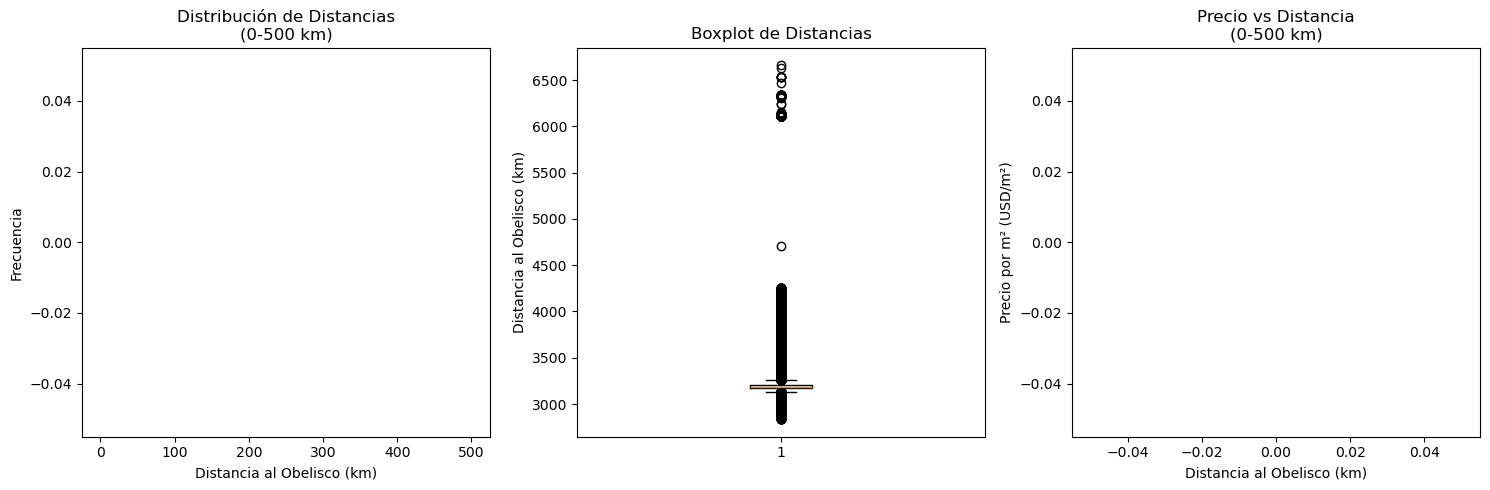


Estadísticas detalladas de distancia al Obelisco:
count    244475.000000
mean       3250.141453
std         249.058181
min        2837.966991
10%        3137.638322
25%        3175.570370
50%        3181.037546
75%        3207.849061
90%        3425.700623
max        6658.302914
Name: distancia_obelisco, dtype: float64

Distribución por rangos de distancia:
rango_distancia
0-10km            0
10-50km           0
50-100km          0
100-500km         0
>500km       244475
Name: count, dtype: int64


In [64]:
# Análisis detallado de las distancias
plt.figure(figsize=(15, 5))

# Subplot 1: Histograma con bins más pequeños y enfoque en los primeros 500km
plt.subplot(1, 3, 1)
plt.hist(df['distancia_obelisco'], bins=50, range=(0, 500))
plt.xlabel('Distancia al Obelisco (km)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Distancias\n(0-500 km)')

# Subplot 2: Boxplot para ver la distribución y outliers
plt.subplot(1, 3, 2)
plt.boxplot(df['distancia_obelisco'])
plt.ylabel('Distancia al Obelisco (km)')
plt.title('Boxplot de Distancias')

# Subplot 3: Scatter plot de precios vs distancia (limitado a 500km)
plt.subplot(1, 3, 3)
mask = df['distancia_obelisco'] <= 500
plt.scatter(df.loc[mask, 'distancia_obelisco'], 
           df.loc[mask, 'price_m2'], 
           alpha=0.5)
plt.xlabel('Distancia al Obelisco (km)')
plt.ylabel('Precio por m² (USD/m²)')
plt.title('Precio vs Distancia\n(0-500 km)')

plt.tight_layout()
plt.show()

# Estadísticas detalladas de las distancias
print("\nEstadísticas detalladas de distancia al Obelisco:")
print(df['distancia_obelisco'].describe([0.1, 0.25, 0.5, 0.75, 0.9]))

# Distribución por rangos de distancia
rangos = [0, 10, 50, 100, 500, float('inf')]
labels = ['0-10km', '10-50km', '50-100km', '100-500km', '>500km']
df['rango_distancia'] = pd.cut(df['distancia_obelisco'], bins=rangos, labels=labels)

print("\nDistribución por rangos de distancia:")
print(df['rango_distancia'].value_counts().sort_index())


In [65]:
# Crear TabularPandas
to = TabularPandas(df, procs, cat, cont, y_names='price_m2', splits=splits)

# === BLOQUE SEGURO: usar salidas de TabularPandas para evitar NaN ===
try:
    X_train, y_train = to.train.xs.copy(), to.train.y.values.ravel()
    X_valid, y_valid = to.valid.xs.copy(), to.valid.y.values.ravel()
except NameError as e:
    raise RuntimeError("No existe el objeto 'to'. Asegúrate de haber creado TabularPandas antes.") from e

# Chequeos duros de NaN (deben dar 0)
print("NaN en X_train:", int(X_train.isna().sum().sum()))
print("NaN en X_valid:", int(X_valid.isna().sum().sum()))

# Guardar el objeto TabularPandas procesado
save_pickle('./df_train-tabular-object.pkl', to)

c:\Users\60083400\AppData\Local\anaconda3\Lib\site-packages\fastai\tabular\core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)
c:\Users\60083400\AppData\Local\anaconda3\Lib\site-packages\fastai\tabular\core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

NaN en X_train: 0
NaN en X_valid: 0
